# GraceDB BNS/NSBH SESN 3D Crossmatch (Refactor)

*This is a refactor of the original gracedb_sesn_3d_crossmatch.ipynb notebook. It replaces constants and functions previously define within the notebook with calls to modules that do the same.*

This notebook downloads public GraceDB production superevents passing the configured FAR threshold, keeps superevents passing the configured BNS/NSBH probability cut, downloads the best available 3D sky map, and crossmatches stripped-envelope supernovae from TNS.

The workflow is:

1. Download and filter the TNS public catalog for SESN-like types near the configured distance limit.
2. Query GraceDB superevents, fetch `p_astro.json` classifications, and download one best available multiorder FITS skymap per passing superevent.
3. Reproduce the temporal match from `how_many_SESN.ipynb` using the configured discovery-time window.
4. Run a configurable 3D credible-volume crossmatch twice: once with SN luminosity distances from the SHOES cosmology and once with `Planck18`.
5. If any SN lands inside the configured 3D credible volume, save diagnostic overlap plots to `gracedb_sesn_3d_plots/`.


In [1]:
# For development, automatically reload modules when they change

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

## Get transients from TNS

In [3]:
from desi_aap.tns_catalog import download_tns_table, clean_tns_catalog

In [4]:
import os

os.environ["TNS_API_KEY"] = "174094777967c4c1438cdfd6.00935564"
os.environ["TNS_BOT_ID"] = "105220"
os.environ["TNS_BOT_NAME"] = "DESIRT_Bot"

In [5]:
tns_raw = download_tns_table()
df_sesn = clean_tns_catalog(tns_raw)

df_sesn

,name,ra,declination,redshift,type,discoverydate,reporting_group,internal_names,dist_mpc_SHOES,dist_mpc_Planck18
0,2026pef,303.625501,5.097798,0.060,SN Ib,2026-06-07 09:14:46.999000+00:00,ZTF,"ZTF26abasrob, GOTO26fyr",257.478075,277.813361
1,2026oxz,9.582479,-5.258983,0.100,SN Ic,2026-06-08 11:14:55.999000+00:00,ZTF,"ZTF26abbaxhz, GOTO26ggx, ATLAS26hrt, PS26dyh,",441.138223,475.822268
...,...,...,...,...,...,...,...,...,...,...
1429,2016G,45.990417,43.401000,0.009,SN Ic-BL,2016-01-09 22:26:24+00:00,NaN,", Gaia16acf",37.197287,40.152037
1430,2015bi,218.063750,26.325444,0.016,SN IIb,2015-12-31 14:52:48+00:00,ASAS-SN,"ASASSN-15uy, Gaia16abm",66.481600,71.758366


In [6]:
col_name = "dist_mpc_Planck18"  # SHOES

min_dist = df_sesn[col_name].min()
max_dist = df_sesn[col_name].max()

print("Minimum distance:", min_dist)
print("Maximum distance:", max_dist)

Minimum distance: 8.386463760783569
Maximum distance: 537.1370620670143


## Get GraceDB superevents

In [7]:
from desi_aap.gracedb_tools import (
    display_coincidences,
    display_temporal_summary,
    fetch_gracedb_superevents,
    run_3d_spatial_crossmatch,
    select_coincidences,
    summarize_temporal_matches,
)

/Users/orl/envs/p312/lib/python3.12/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [8]:
gracedb_events = fetch_gracedb_superevents(se_types=["BNS", "NSBH"])
gracedb_events

,superevent_id,gw_time,gps_time,far_hz,far_per_year,p_bns,p_nsbh,p_bbh,p_terrestrial,classification_file,preferred_event,pipeline,search,instruments,labels,skymap_file,skymap_path,status
0,S190425z,2019-04-25 08:18:05.011549+00:00,1.240216e+09,4.537648e-13,1.431973e-05,9.994026e-01,0.000000,0.000000e+00,5.974329e-04,p_astro.json,G330564,gstlal,AllSky,"L1,V1","ADVOK,SKYMAP_READY,EMBRIGHT_READY,PASTRO_READY...",GW190425_PublicationSamples.multiorder.fits,gracedb_skymaps/S190425z__GW190425_Publication...,ok
1,S190814bv,2019-08-14 21:10:39.012957+00:00,1.249852e+09,2.032625e-33,6.414477e-26,0.000000e+00,0.997890,0.000000e+00,0.000000e+00,p_astro.json,G347305,gstlal,AllSky,"H1,L1,V1","PE_READY,ADVOK,SKYMAP_READY,EMBRIGHT_READY,PAS...",bayestar.multiorder.fits,gracedb_skymaps/S190814bv__bayestar.multiorder...,ok
2,S190822c,2019-08-22 01:29:59.589203+00:00,1.250473e+09,6.145185e-18,1.939273e-10,1.000000e+00,0.000000,0.000000e+00,5.223321e-10,p_astro.json,G347846,gstlal,AllSky,"L1,V1","ADVNO,SKYMAP_READY,EMBRIGHT_READY,PASTRO_READY...",bayestar.multiorder.fits,gracedb_skymaps/S190822c__bayestar.multiorder....,ok
3,S190910d,2019-09-10 01:26:19.242676+00:00,1.252114e+09,3.717180e-09,1.173053e-01,0.000000e+00,0.975899,0.000000e+00,2.410074e-02,p_astro.json,G350002,spiir,HighMass,"H1,L1","PE_READY,ADVOK,SKYMAP_READY,EMBRIGHT_READY,PAS...",bayestar.multiorder.fits,gracedb_skymaps/S190910d__bayestar.multiorder....,ok
4,S191117j,2019-11-17 06:08:22.454868+00:00,1.258006e+09,1.114482e-18,3.517037e-11,0.000000e+00,1.000000,0.000000e+00,1.080973e-10,p_astro.json,G354833,gstlal,AllSky,"H1,L1","ADVNO,EM_Selected,SKYMAP_READY,EMBRIGHT_READY,...",bayestar.multiorder.fits,gracedb_skymaps/S191117j__bayestar.multiorder....,ok
5,S191205ah,2019-12-05 21:52:08.568738+00:00,1.259618e+09,1.248393e-08,3.939628e-01,0.000000e+00,0.932102,0.000000e+00,6.789774e-02,p_astro.json,G356642,gstlal,AllSky,"H1,L1,V1","EM_READY,ADVOK,EM_Selected,SKYMAP_READY,EMBRIG...",bayestar.multiorder.fits,gracedb_skymaps/S191205ah__bayestar.multiorder...,ok
6,S191220af,2019-12-20 12:24:14.690032+00:00,1.260880e+09,3.963175e-10,1.250683e-02,9.963550e-01,0.000000,0.000000e+00,3.644999e-03,p_astro.json,G357916,gstlal,AllSky,"L1,V1","EM_READY,PE_READY,ADVNO,EM_Selected,SKYMAP_REA...",bayestar.multiorder.fits,gracedb_skymaps/S191220af__bayestar.multiorder...,ok
7,S200116ah,2020-01-16 11:56:42.170712+00:00,1.263211e+09,2.028966e-12,6.402930e-05,0.000000e+00,0.999934,0.000000e+00,6.579270e-05,p_astro.json,G360499,gstlal,AllSky,"H1,L1","EM_READY,PE_READY,ADVNO,EM_Selected,SKYMAP_REA...",bayestar.multiorder.fits,gracedb_skymaps/S200116ah__bayestar.multiorder...,ok
8,S230529ay,2023-05-29 18:15:00.746094+00:00,1.369419e+09,1.975121e-10,6.233008e-03,3.060151e-01,0.624028,0.000000e+00,6.995704e-02,pycbc.p_astro.json,G408702,pycbc,AllSky,L1,"EM_READY,PE_READY,ADVOK,SKYMAP_READY,EMBRIGHT_...",Bilby.multiorder.fits,gracedb_skymaps/S230529ay__Bilby.multiorder.fits,ok
9,S230715bw,2023-07-15 19:05:37.952637+00:00,1.373483e+09,7.843396e-09,2.475188e-01,0.000000e+00,0.906988,8.832113e-02,4.690587e-03,spiir.p_astro.json,G417598,spiir,AllSky,"H1,L1","EM_READY,PE_READY,ADVNO,SKYMAP_READY,EMBRIGHT_...",bayestar.multiorder.fits,gracedb_skymaps/S230715bw__bayestar.multiorder...,ok


## Run temporal crossmatch between transients (SESN) and superevents (GW)

In [9]:
from desi_aap.gracedb_tools import temporal_crossmatch_sesn_to_gw

In [10]:
df_sesn_gracedb_temporal = temporal_crossmatch_sesn_to_gw(df_sesn, gracedb_events)
df_sesn_gracedb_temporal

,name,ra,declination,redshift,type,discoverydate,reporting_group,internal_names,dist_mpc_SHOES,dist_mpc_Planck18,...,gw_p_nsbh,gw_p_bbh,gw_p_terrestrial,gw_preferred_event,gw_pipeline,gw_search,gw_instruments,gw_skymap_file,gw_skymap_path,gw_status
0,2019dgw,287.799129,48.492651,0.095000,SN Ib,2019-04-11 11:47:45+00:00,ZTF,ZTF19aapwnmb,417.673722,450.531339,...,0.000000,0.0,0.000597,G330564,gstlal,AllSky,"L1,V1",GW190425_PublicationSamples.multiorder.fits,gracedb_skymaps/S190425z__GW190425_Publication...,ok
1,2019dps,314.673208,-54.185181,0.044107,SN Ic,2019-04-15 08:23:59+00:00,ASAS-SN,"ASASSN-19kn, Gaia19bky",187.128529,201.934218,...,0.000000,0.0,0.000597,G330564,gstlal,AllSky,"L1,V1",GW190425_PublicationSamples.multiorder.fits,gracedb_skymaps/S190425z__GW190425_Publication...,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2025cav,138.033482,41.317581,0.092000,SN Ic,2025-02-18 22:57:23.328000+00:00,GOTO,"GOTO25amj, ATLAS25btd, PS25yk, WFST0499ckcnz",403.663710,435.429892,...,0.550467,0.0,0.076666,G552809,pycbc,AllSky,"H1,L1",Bilby.multiorder.fits,gracedb_skymaps/S250206dm__Bilby.multiorder.fits,ok
177,2025drb,176.154584,1.885731,0.032000,SN Ic,2025-02-19 17:11:02.400000+00:00,WFST,"WFST0521ofmq, PS25aku",134.564118,145.225446,...,0.550467,0.0,0.076666,G552809,pycbc,AllSky,"H1,L1",Bilby.multiorder.fits,gracedb_skymaps/S250206dm__Bilby.multiorder.fits,ok


In [11]:
gracedb_temporal_summary = summarize_temporal_matches(df_sesn_gracedb_temporal, gracedb_events)

display_temporal_summary(gracedb_temporal_summary)

,superevent_id,gw_time,far_per_year,p_bns,p_nsbh,pipeline,search,skymap_file,n_temporal_sesn,status
0,S190425z,2019-04-25 08:18:05.011549+00:00,1.431973e-05,9.994026e-01,0.000000,gstlal,AllSky,GW190425_PublicationSamples.multiorder.fits,13,ok
1,S190814bv,2019-08-14 21:10:39.012957+00:00,6.414477e-26,0.000000e+00,0.997890,gstlal,AllSky,bayestar.multiorder.fits,20,ok
2,S190822c,2019-08-22 01:29:59.589203+00:00,1.939273e-10,1.000000e+00,0.000000,gstlal,AllSky,bayestar.multiorder.fits,20,ok
3,S190910d,2019-09-10 01:26:19.242676+00:00,1.173053e-01,0.000000e+00,0.975899,spiir,HighMass,bayestar.multiorder.fits,13,ok
4,S191117j,2019-11-17 06:08:22.454868+00:00,3.517037e-11,0.000000e+00,1.000000,gstlal,AllSky,bayestar.multiorder.fits,3,ok
5,S191205ah,2019-12-05 21:52:08.568738+00:00,3.939628e-01,0.000000e+00,0.932102,gstlal,AllSky,bayestar.multiorder.fits,13,ok
6,S191220af,2019-12-20 12:24:14.690032+00:00,1.250683e-02,9.963550e-01,0.000000,gstlal,AllSky,bayestar.multiorder.fits,16,ok
7,S200116ah,2020-01-16 11:56:42.170712+00:00,6.402930e-05,0.000000e+00,0.999934,gstlal,AllSky,bayestar.multiorder.fits,20,ok
8,S230529ay,2023-05-29 18:15:00.746094+00:00,6.233008e-03,3.060151e-01,0.624028,pycbc,AllSky,Bilby.multiorder.fits,10,ok
9,S230715bw,2023-07-15 19:05:37.952637+00:00,2.475188e-01,0.000000e+00,0.906988,spiir,AllSky,bayestar.multiorder.fits,7,ok


**About 2D vs 3D Ranking**

`ligo.skymap.postprocess.crossmatch` reports two different rankings. `searched_prob_2d` is the sky-only credible level after marginalizing over distance. `searched_prob_vol` is a 3D voxel credible level ranked by posterior density per volume at `(RA, Dec, distance)`. These are not nested quantities, so `searched_prob_vol` can be much smaller than `searched_prob_2d` when the SN distance falls on a high-density distance slice even if the sky position is not in the highest-probability sky pixels.

In [12]:
df_sesn_gracedb_3d = run_3d_spatial_crossmatch(df_sesn_gracedb_temporal, gracedb_events)
df_sesn_gracedb_3d

,name,ra,declination,redshift,type,discoverydate,reporting_group,internal_names,dist_mpc_SHOES,dist_mpc_Planck18,...,searched_prob_dist,searched_vol_mpc3,searched_prob_vol,searched_prob_3d_density_rank,probdensity_vol,credible_volume_mpc3,credible_area_deg2,inside_2d_credible_level,inside_3d_credible_level,spatial_status
0,2019dgw,287.799129,48.492651,0.095,SN Ib,2019-04-11 11:47:45+00:00,ZTF,ZTF19aapwnmb,417.673722,450.531339,...,1.000000,1.661173e+08,1.000004,1.000004,5.397701e-22,2.144799e+06,2400.292101,False,False,ok
1,2019dgw,287.799129,48.492651,0.095,SN Ib,2019-04-11 11:47:45+00:00,ZTF,ZTF19aapwnmb,417.673722,450.531339,...,0.999999,1.367708e+08,1.000004,1.000004,1.117510e-19,2.144799e+06,2400.292101,False,False,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354,2025drb,176.154584,1.885731,0.032,SN Ic,2025-02-19 17:11:02.400000+00:00,WFST,"WFST0521ofmq, PS25aku",134.564118,145.225446,...,0.031100,4.013170e+09,0.999996,0.999996,0.000000e+00,1.666301e+06,221.882883,False,False,ok
355,2025drb,176.154584,1.885731,0.032,SN Ic,2025-02-19 17:11:02.400000+00:00,WFST,"WFST0521ofmq, PS25aku",134.564118,145.225446,...,0.023635,4.013171e+09,0.999996,0.999996,0.000000e+00,1.666301e+06,221.882883,False,False,ok


In [13]:
coincidence_sne = select_coincidences(df_sesn_gracedb_3d, require_2d_credible_level=True)

display_coincidences(coincidence_sne)

,superevent_id,gw_time,gw_far_per_year,gw_p_bns,gw_p_nsbh,name,type,discoverydate,days_from_gw,redshift,...,searched_prob_dist,searched_area_deg2,credible_area_deg2,credible_volume_mpc3,inside_2d_credible_level,inside_3d_credible_level,ra,declination,reporting_group,internal_names
0,S190425z,2019-04-25 08:18:05.011549+00:00,1.431973e-05,0.999403,0.000000,2019ebq,SN Ib/c,2019-04-25 12:11:31+00:00,0.162106,0.037,...,0.602471,255.564915,2400.292101,2.144799e+06,True,True,255.326411,-7.002923,Pan-STARRS,PS19qp
1,S190425z,2019-04-25 08:18:05.011549+00:00,1.431973e-05,0.999403,0.000000,2019ebq,SN Ib/c,2019-04-25 12:11:31+00:00,0.162106,0.037,...,0.499138,255.564915,2400.292101,2.144799e+06,True,True,255.326411,-7.002923,Pan-STARRS,PS19qp
2,S190425z,2019-04-25 08:18:05.011549+00:00,1.431973e-05,0.999403,0.000000,2019eff,SN IIb,2019-04-25 13:59:31+00:00,0.237106,0.050,...,0.936488,3.147351,2400.292101,2.144799e+06,True,True,248.413109,13.910201,Pan-STARRS,"PS19sh, ZTF19aasckkq"
3,S190425z,2019-04-25 08:18:05.011549+00:00,1.431973e-05,0.999403,0.000000,2019eff,SN IIb,2019-04-25 13:59:31+00:00,0.237106,0.050,...,0.881450,3.147351,2400.292101,2.144799e+06,True,True,248.413109,13.910201,Pan-STARRS,"PS19sh, ZTF19aasckkq"
4,S190814bv,2019-08-14 21:10:39.012957+00:00,6.414477e-26,0.000000,0.997890,2019npv,SN Ib,2019-08-16 07:45:07+00:00,1.440602,0.056,...,0.374119,4.802989,7.403113,2.628749e+04,True,True,13.384619,-23.832957,DECam-GROWTH,"DG19wxnjc, PS19eqi"
5,S190814bv,2019-08-14 21:10:39.012957+00:00,6.414477e-26,0.000000,0.997890,2019npv,SN Ib,2019-08-16 07:45:07+00:00,1.440602,0.056,...,0.253252,4.802989,7.403113,2.628749e+04,True,True,13.384619,-23.832957,DECam-GROWTH,"DG19wxnjc, PS19eqi"
6,S230715bw,2023-07-15 19:05:37.952637+00:00,2.475188e-01,0.000000,0.906988,2023zkd,SN Ibn,2023-07-07 04:36:28.800000+00:00,-8.603578,0.056,...,0.038559,1444.214540,4680.685591,2.341204e+08,True,True,237.198109,9.200040,ZTF,"ZTF23aasnwva, ATLAS24kty, PS23nwd"
7,S230715bw,2023-07-15 19:05:37.952637+00:00,2.475188e-01,0.000000,0.906988,2023zkd,SN Ibn,2023-07-07 04:36:28.800000+00:00,-8.603578,0.056,...,0.032289,1444.214540,4680.685591,2.341204e+08,True,True,237.198109,9.200040,ZTF,"ZTF23aasnwva, ATLAS24kty, PS23nwd"


## Plot results

In [14]:
from desi_aap.skymap_plots import plot_3d_coincidence

/Users/orl/envs/p312/lib/python3.12/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


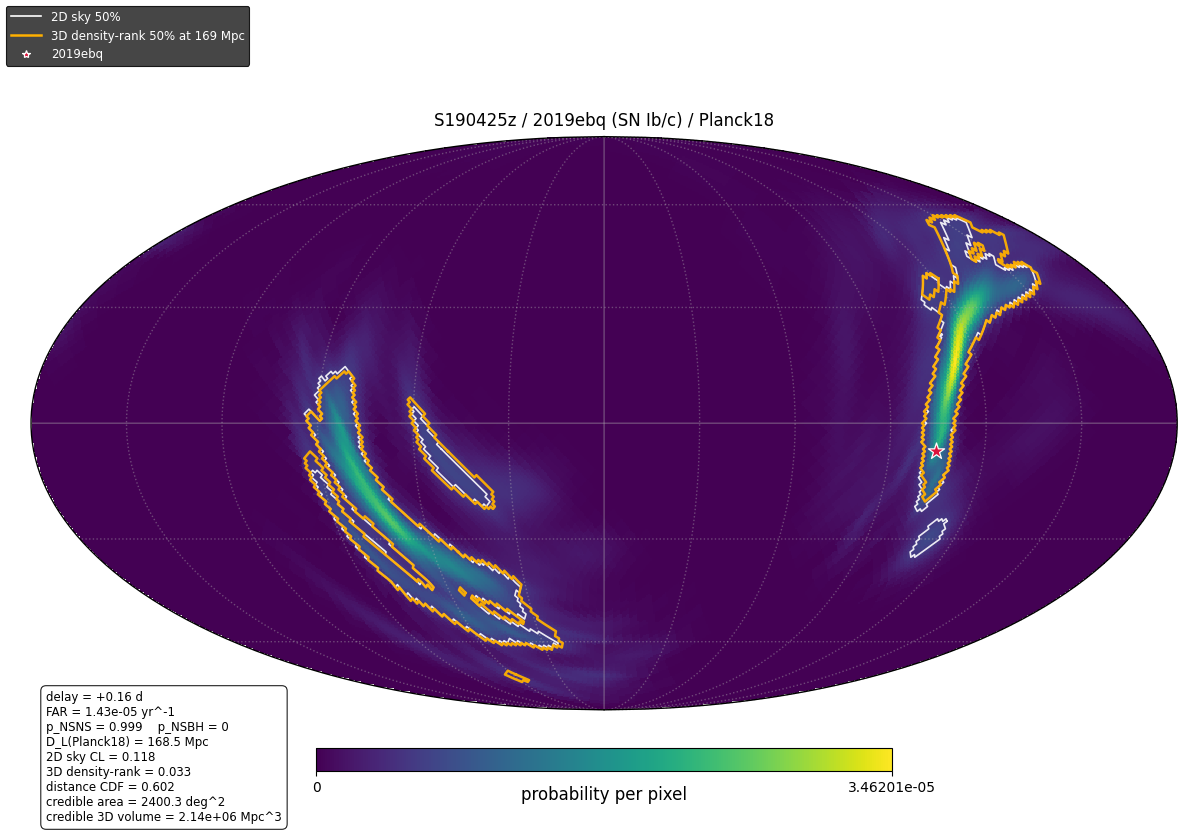

In [15]:
# Try a single plot

if not coincidence_sne.empty:
    plot_3d_coincidence(coincidence_sne.iloc[0], gracedb_events, show=True)


# # Run all

# plot_paths = []
# if not coincidence_sne.empty:
#     for i, row in coincidence_sne.iterrows():
#         plot_paths.append(plot_3d_coincidence(row, gracedb_events))

# pd.DataFrame({"plot_path": [str(path) for path in plot_paths]})